### Importing Packages

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import StandardScaler
import ta


### Get raw data (Yahoo Finance)

In [6]:
# Download the data from Yahoo Finance
df = yf.download('TSLA', start='2018-01-01', end='2024-12-11')

df = df.dropna()
# df = df[['Open', 'High', 'Low', 'Close']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2018-01-02,21.368668,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.427334,22.468000,21.033333,21.066668,147891000


In [7]:
df = df[['Open', 'High', 'Low', 'Adj Close', 'Volume']]
df.columns.tolist()


[('Open', 'TSLA'),
 ('High', 'TSLA'),
 ('Low', 'TSLA'),
 ('Adj Close', 'TSLA'),
 ('Volume', 'TSLA')]

In [9]:
df = df.droplevel(axis=1, level=1)
df

Price,Open,High,Low,Adj Close,Volume
Date,,,,,
2018-01-02,20.799999,21.474001,20.733334,21.368668,65283000
2018-01-03,21.400000,21.683332,21.036667,21.150000,67822500
2018-01-04,20.858000,21.236668,20.378668,20.974667,149194500
2018-01-05,21.108000,21.149332,20.799999,21.105333,68868000
2018-01-08,21.066668,22.468000,21.033333,22.427334,147891000
...,...,...,...,...,...
2024-12-04,353.000000,358.100006,348.600006,357.929993,50810900
2024-12-05,359.869995,375.429993,359.500000,369.489990,81403600
2024-12-06,377.420013,389.489990,370.799988,389.220001,81455800


In [10]:
df.rename(columns={'Adj Close' : 'Close'}, inplace=True)

In [14]:
import ta.momentum


df['O-C'] = df.Open - df.Close
df['H-L'] = df.High - df.Low
df['3day MA'] = df.Close.shift(1).rolling(window=3).mean()
df['10day MA'] = df.Close.shift(1).rolling(window=10).mean()
df['30day MA'] = df.Close.shift(1).rolling(window=30).mean()
df['Std_dev'] = df.Close.rolling(5).std()

# Using ta for RSI
df['RSI'] = ta.momentum.RSIIndicator(df.Close, window=9).rsi()

# Using pandas-ta for Williams %R
df['Williams %R'] = ta.momentum.WilliamsRIndicator(high=df['High'], low=df['Low'], close=df['Close'], lbp=7).williams_r()

df = df.dropna()
df.head()

Price,Open,High,Low,Close,Volume,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R
Date,,,,,,,,,,,,,
2018-02-14,21.389334,21.744667,21.234667,21.487333,59260500,-0.098000,0.510000,21.106890,22.163000,22.400867,0.364370,42.108104,-48.848871
2018-02-15,21.633333,22.274668,21.493334,22.271334,88693500,-0.638000,0.781334,21.371112,21.949667,22.404822,0.595392,52.171565,-27.014469
2018-02-16,22.166668,22.874666,22.109333,22.365999,84639000,-0.199331,0.765333,21.778667,21.848467,22.442200,0.557207,53.274902,-24.378035
2018-02-20,22.298000,22.722668,22.100000,22.318001,60141000,-0.020000,0.622667,22.041555,21.793400,22.488578,0.433040,52.582984,-17.266302
2018-02-21,22.402000,22.646000,22.211332,22.219999,48294000,0.182001,0.434668,22.318445,21.804334,22.529000,0.364727,51.059742,-26.634148


In [15]:
df.Close.shift(-1)

Date
2018-02-14     22.271334
2018-02-15     22.365999
2018-02-16     22.318001
2018-02-20     22.219999
2018-02-21     23.077999
                 ...    
2024-12-04    369.489990
2024-12-05    389.220001
2024-12-06    389.790009
2024-12-09    400.989990
2024-12-10           NaN
Name: Close, Length: 1717, dtype: float64

In [16]:
df['Price_Rise'] = np.where(df.Close.shift(-1) > df.Close, 1, 0)
df = df.dropna()
df.head()

C:\Users\User_SevenShop\AppData\Local\Temp\ipykernel_14396\3473548541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price_Rise'] = np.where(df.Close.shift(-1) > df.Close, 1, 0)


Price,Open,High,Low,Close,Volume,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise
Date,,,,,,,,,,,,,,
2018-02-14,21.389334,21.744667,21.234667,21.487333,59260500,-0.098000,0.510000,21.106890,22.163000,22.400867,0.364370,42.108104,-48.848871,1
2018-02-15,21.633333,22.274668,21.493334,22.271334,88693500,-0.638000,0.781334,21.371112,21.949667,22.404822,0.595392,52.171565,-27.014469,1
2018-02-16,22.166668,22.874666,22.109333,22.365999,84639000,-0.199331,0.765333,21.778667,21.848467,22.442200,0.557207,53.274902,-24.378035,0
2018-02-20,22.298000,22.722668,22.100000,22.318001,60141000,-0.020000,0.622667,22.041555,21.793400,22.488578,0.433040,52.582984,-17.266302,0
2018-02-21,22.402000,22.646000,22.211332,22.219999,48294000,0.182001,0.434668,22.318445,21.804334,22.529000,0.364727,51.059742,-26.634148,1


In [17]:
feature_names = [f for f in df.columns if f not in ['Price_Rise', 'Open', 'High', 'Low', 'Close', 'Volume']]
feature_names

['O-C',
 'H-L',
 '3day MA',
 '10day MA',
 '30day MA',
 'Std_dev',
 'RSI',
 'Williams %R']

In [18]:
# input and output data
X = df[feature_names]
y = df['Price_Rise']

split = int(len(df)*0.8)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

In [19]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
# Let's run the model using the selected variables
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
logsk = LogisticRegression(solver='lbfgs')
logsk.fit(X_train, y_train)

LogisticRegression()

In [22]:
logsk.predict_proba(X_test)


array([[0.48191705, 0.51808295],
       [0.47898045, 0.52101955],
       [0.50519941, 0.49480059],
       [0.47387926, 0.52612074],
       [0.50834783, 0.49165217],
       [0.50324499, 0.49675501],
       [0.47885892, 0.52114108],
       [0.49021849, 0.50978151],
       [0.49971548, 0.50028452],
       [0.51516079, 0.48483921],
       [0.4998526 , 0.5001474 ],
       [0.51016218, 0.48983782],
       [0.5121064 , 0.4878936 ],
       [0.53034031, 0.46965969],
       [0.53141837, 0.46858163],
       [0.52284265, 0.47715735],
       [0.53258422, 0.46741578],
       [0.51410366, 0.48589634],
       [0.5406696 , 0.4593304 ],
       [0.51785609, 0.48214391],
       [0.50298153, 0.49701847],
       [0.46291483, 0.53708517],
       [0.46298658, 0.53701342],
       [0.46943979, 0.53056021],
       [0.50480807, 0.49519193],
       [0.47950007, 0.52049993],
       [0.48374367, 0.51625633],
       [0.45890628, 0.54109372],
       [0.4756991 , 0.5243009 ],
       [0.44963799, 0.55036201],
       [0.

In [23]:
logsk.predict(X_test)

array([1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [24]:
# Predicted probabilities
y_pred = logsk.predict_proba(X_test)

y_pred = logsk.predict(X_test)
y_pred = (y_pred > 0.5)

In [27]:
len(df)

1717

In [ ]:
df.iloc[(len(df) - len(y_pred)):,-1:]

Price,Price_Rise
Date,
2023-08-01,0
2023-08-02,1
2023-08-03,0
2023-08-04,0
2023-08-07,0
...,...
2024-12-04,1
2024-12-05,1
2024-12-06,1


In [29]:
df['y_pred'] = np.nan
df.iloc[(len(df) - len(y_pred)):,-1:] = y_pred.astype(np.float64)
trade_df = df.dropna()

In [31]:
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
# help(metrics.confusion_matrix)

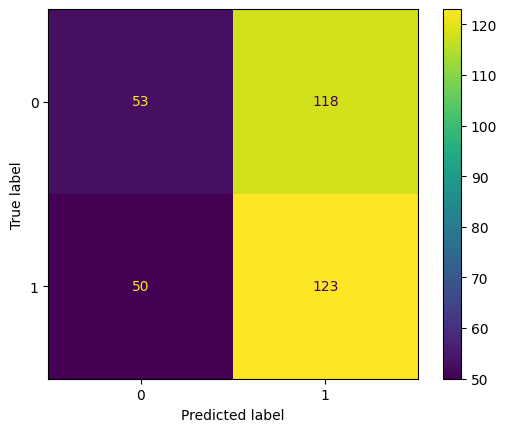

In [32]:
import matplotlib.pyplot as plt
confusion = metrics.confusion_matrix(y_true=y_test, y_pred=y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion,
                              display_labels=logsk.classes_)
disp.plot()
plt.show()

In [33]:
trade_df = df.dropna().copy()  # Explicitly create a copy
trade_df['Tomorrows Returns'] = 0.
trade_df['Tomorrows Returns'] = np.log(trade_df['Close']/trade_df['Close'].shift(1))
trade_df['Tomorrows Returns'] = trade_df['Tomorrows Returns'].shift(-1)
trade_df.head()

Price,Open,High,Low,Close,Volume,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise,y_pred,Tomorrows Returns
Date,,,,,,,,,,,,,,,,
2023-08-01,266.260010,266.470001,260.250000,261.070007,83166000,5.190002,6.220001,263.193334,269.578999,268.418000,4.747364,44.041194,-62.992478,0,1.0,-0.027021
2023-08-02,255.570007,259.519989,250.490005,254.110001,101752900,1.460007,9.029984,264.980001,266.352000,268.435666,6.049544,38.699391,-83.846511,1,1.0,0.020296
2023-08-03,252.039993,260.489990,252.000000,259.320007,97569100,-7.280014,8.489990,260.870000,262.637000,267.757666,5.453586,44.380546,-52.628744,0,0.0,-0.021280
2023-08-04,260.970001,264.769989,253.110001,253.860001,99242600,7.110001,11.659988,258.166672,262.279001,267.753000,5.604886,40.008983,-81.920626,0,1.0,-0.009539
2023-08-07,251.449997,253.649994,242.759995,251.449997,111097900,0.000000,10.889999,255.763336,261.663002,267.394667,4.048902,38.143293,-66.983263,0,0.0,-0.006984


In [34]:
trade_df['Strategy Returns'] = 0.
trade_df['Strategy Returns'] = np.where(trade_df['y_pred'] == True, trade_df['Tomorrows Returns'], - trade_df['Tomorrows Returns'])
trade_df.head()

Price,Open,High,Low,Close,Volume,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise,y_pred,Tomorrows Returns,Strategy Returns
Date,,,,,,,,,,,,,,,,,
2023-08-01,266.260010,266.470001,260.250000,261.070007,83166000,5.190002,6.220001,263.193334,269.578999,268.418000,4.747364,44.041194,-62.992478,0,1.0,-0.027021,-0.027021
2023-08-02,255.570007,259.519989,250.490005,254.110001,101752900,1.460007,9.029984,264.980001,266.352000,268.435666,6.049544,38.699391,-83.846511,1,1.0,0.020296,0.020296
2023-08-03,252.039993,260.489990,252.000000,259.320007,97569100,-7.280014,8.489990,260.870000,262.637000,267.757666,5.453586,44.380546,-52.628744,0,0.0,-0.021280,0.021280
2023-08-04,260.970001,264.769989,253.110001,253.860001,99242600,7.110001,11.659988,258.166672,262.279001,267.753000,5.604886,40.008983,-81.920626,0,1.0,-0.009539,-0.009539
2023-08-07,251.449997,253.649994,242.759995,251.449997,111097900,0.000000,10.889999,255.763336,261.663002,267.394667,4.048902,38.143293,-66.983263,0,0.0,-0.006984,0.006984


In [35]:
trade_df.loc[:, 'Cumulative Market Returns'] = np.cumsum(trade_df['Tomorrows Returns'])
trade_df.loc[:, 'Cumulative Strategy Returns'] = np.cumsum(trade_df['Strategy Returns'])
trade_df.head()

Price,Open,High,Low,Close,Volume,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise,y_pred,Tomorrows Returns,Strategy Returns,Cumulative Market Returns,Cumulative Strategy Returns
Date,,,,,,,,,,,,,,,,,,,
2023-08-01,266.260010,266.470001,260.250000,261.070007,83166000,5.190002,6.220001,263.193334,269.578999,268.418000,4.747364,44.041194,-62.992478,0,1.0,-0.027021,-0.027021,-0.027021,-0.027021
2023-08-02,255.570007,259.519989,250.490005,254.110001,101752900,1.460007,9.029984,264.980001,266.352000,268.435666,6.049544,38.699391,-83.846511,1,1.0,0.020296,0.020296,-0.006726,-0.006726
2023-08-03,252.039993,260.489990,252.000000,259.320007,97569100,-7.280014,8.489990,260.870000,262.637000,267.757666,5.453586,44.380546,-52.628744,0,0.0,-0.021280,0.021280,-0.028006,0.014554
2023-08-04,260.970001,264.769989,253.110001,253.860001,99242600,7.110001,11.659988,258.166672,262.279001,267.753000,5.604886,40.008983,-81.920626,0,1.0,-0.009539,-0.009539,-0.037544,0.005015
2023-08-07,251.449997,253.649994,242.759995,251.449997,111097900,0.000000,10.889999,255.763336,261.663002,267.394667,4.048902,38.143293,-66.983263,0,0.0,-0.006984,0.006984,-0.044528,0.011999


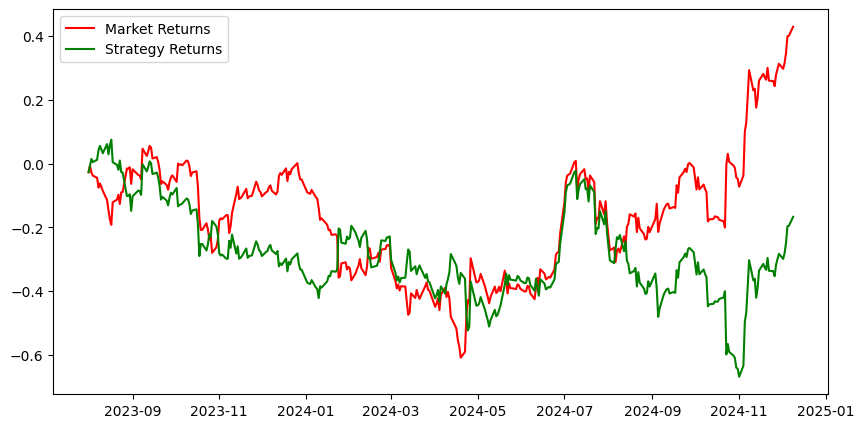

In [36]:
plt.figure(figsize=(10,5))
plt.plot(trade_df['Cumulative Market Returns'], color='r', label='Market Returns')
plt.plot(trade_df['Cumulative Strategy Returns'], color='g', label='Strategy Returns')
plt.legend()
plt.show()

In [37]:
TP_trades = trade_df[(trade_df.y_pred==True) & (trade_df['Tomorrows Returns']>0)]['Tomorrows Returns']
FP_trades = trade_df[(trade_df.y_pred==True) & (trade_df['Tomorrows Returns']<=0)]['Tomorrows Returns']
print(f"Number of TP Trades: {TP_trades.shape[0]}\nCumulative TP Returns: {TP_trades.sum():.2f}\n ---")
print(f"Number of FP Trades: {FP_trades.shape[0]}\nCumulative FP Returns: {FP_trades.sum():.2f}\n ---")
print(f"Model Precision: {TP_trades.shape[0]/(FP_trades.shape[0]+TP_trades.shape[0]):.3f}\n ---")
print(f"Number of ALL Trades: {FP_trades.shape[0]+TP_trades.shape[0]}\nCumulative Strategy Returns: {FP_trades.sum()+TP_trades.sum():.2f}\n ---")

Number of TP Trades: 123
Cumulative TP Returns: 3.12
 ---
Number of FP Trades: 117
Cumulative FP Returns: -2.99
 ---
Model Precision: 0.512
 ---
Number of ALL Trades: 240
Cumulative Strategy Returns: 0.13
 ---
